# Laguerre-Gauss Modes
Laguerre-Gaussian (LG) modes constitute another complete set of solutions to the paraxial wave equation. Unlike Hermite-Gaussian modes, which are naturally expressed in Cartesian coordinates, Laguerre-Gaussian modes are defined in cylindrical coordinates and are therefore particularly well suited to optical systems possessing cylindrical symmetry.

Interest in Laguerre-Gaussian modes extends beyond mathematical convenience. In the context of gravitational-wave detectors, higher-order Laguerre-Gaussian beams have been proposed as alternatives to the fundamental Gaussian mode because their broader intensity distributions can reduce the impact of mirror thermal noise, thereby improving detector sensitivity.

---

## Helical Laguerre-Gauss Modes
The general form of a helical Laguerre-Gaussian mode is

$$
u_{p,l}(r,\phi,z)=
\frac{1}{w(z)}
\sqrt{\frac{2\,p!}{\pi (|l|+p)!}}
\exp\!\left[i(2p+|l|+1)\Psi(z)\right]
\left(
\frac{\sqrt{2}r}{w(z)}
\right)^{|l|}
L_p^{|l|}
\!\left(
\frac{2r^2}{w^2(z)}
\right)
\exp\!\left(
-\frac{ikr^2}{2q(z)}
+i l\phi
\right),
$$

where $r$, $\phi$, and $z$ are cylindrical coordinates, $p$ is the radial mode index, $l$ is the azimuthal mode index, and $L_p^{|l|}(x)$ denotes the associated Laguerre polynomial.

The associated Laguerre polynomials are defined by

$$
L_p^{|l|}(x)
=
\frac{1}{p!}
\sum_{j=0}^{p}
\frac{p!}{j!}
\binom{|l|+p}{p-j}
(-x)^j.
$$

All other beam parameters, including the beam radius $w(z)$, beam parameter $q(z)$, Rayleigh range, and Gouy phase, retain the same definitions as for Hermite-Gaussian modes.

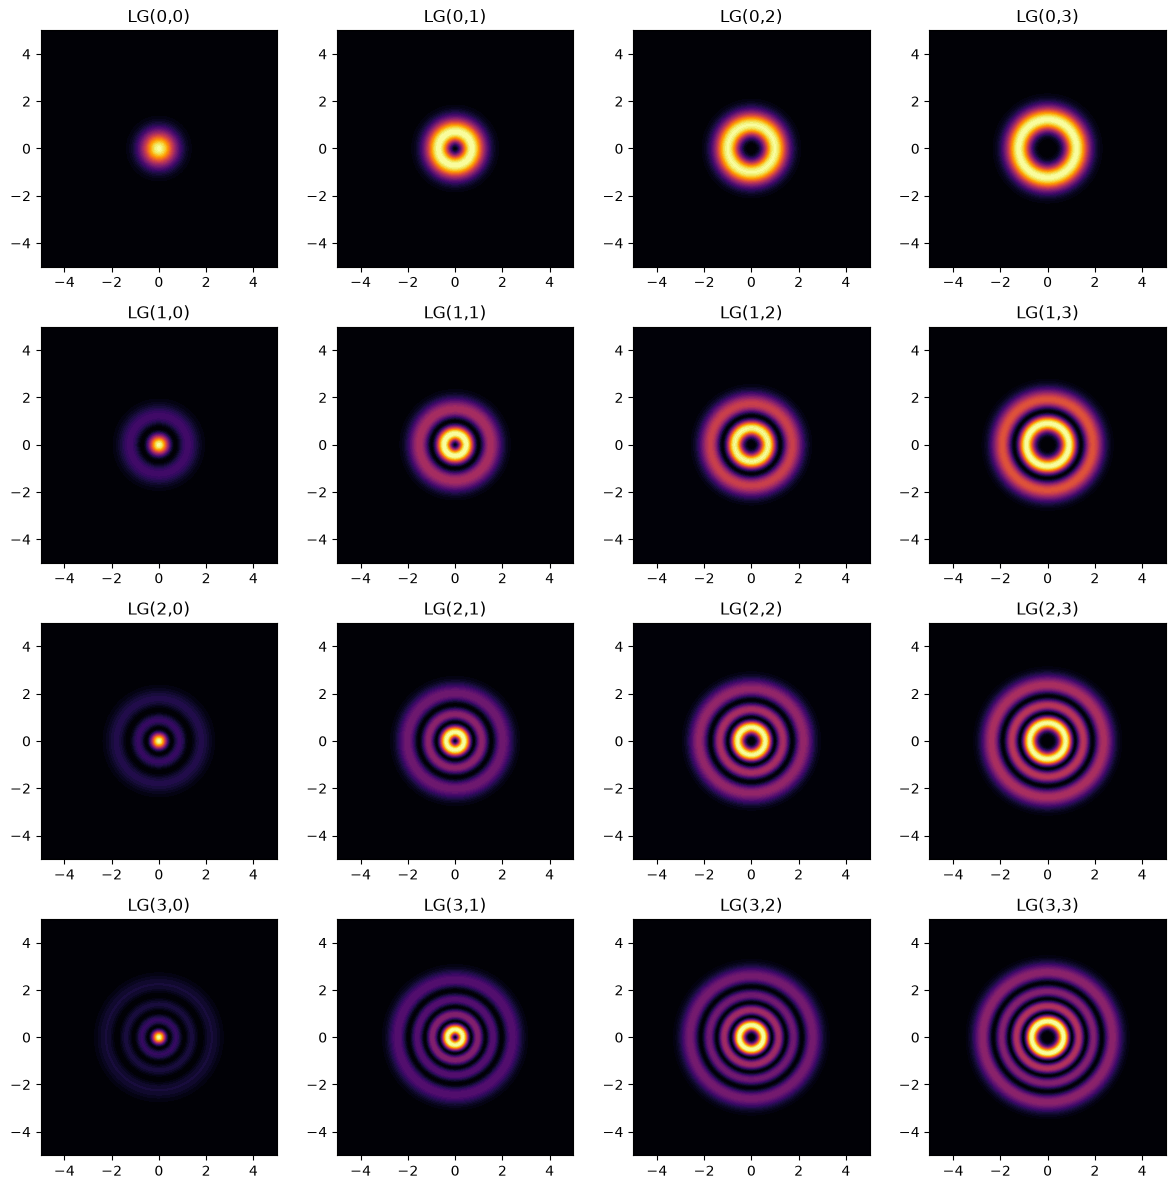

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre, factorial

def laguerre_gauss(p, l, X, Y, w0=1.0):
    """
    Helical Laguerre-Gauss mode LG(p,l) at z = 0.

    Parameters
    p (int) : Radial index (p >= 0)
    l (int) : Azimuthal index
    X, Y (ndarray) : Meshgrid coordinates
    w0 (float) : Beam waist

    Returns
    U (complex ndarray): Complex field amplitude
    """

    r = np.sqrt(X**2 + Y**2)
    phi = np.arctan2(Y, X)
    rho = 2 * r**2 / w0**2
    L = genlaguerre(p, abs(l))(rho)
    norm = np.sqrt(2 * factorial(p) / (np.pi * factorial(p + abs(l))))
    U = (norm * (np.sqrt(2) * r / w0)**abs(l) * L * np.exp(-r**2 / w0**2) * np.exp(1j * l * phi))

    return U

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
x = np . linspace ( -5 , 5 , 400)
y = np . linspace ( -5 , 5 , 400)
X , Y = np . meshgrid (x , y )
modes = [(0,0), (0,1), (0,2), (0,3),
        (1,0), (1,1), (1,2), (1,3),
        (2,0), (2,1), (2,2), (2,3),
        (3,0), (3,1), (3,2), (3,3)]

for ax, (p, l) in zip(axes.flatten(), modes):
    E = laguerre_gauss(p, l, X, Y)
    I = np.abs(E)**2

    ax.contourf(X, Y, I, levels=50, cmap='inferno')
    ax.set_title(f'LG({p},{l})')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()


## Sinusoidal Laguerre-Gauss Modes

The helical Laguerre-Gaussian modes described above possess a spiral phase front arising from the azimuthal phase factor $e^{il\phi}$. While this representation is mathematically elegant and directly exhibits the orbital angular momentum of the beam, an alternative form of Laguerre-Gaussian modes is often encountered in optical resonator studies and interferometric simulations.

These modes are obtained by replacing the azimuthal phase factor with a sinusoidal angular dependence, typically $\cos(l\phi)$ or $\sin(l\phi)$. The resulting field distribution may be written as

$$
u^{\mathrm{alt}}_{p,l}(r,\phi,z)
=
\frac{2}{w(z)}
\sqrt{
\frac{p!}
     {(1+\delta_{0l})\pi(|l|+p)!}
}
\exp\!\left[i(2p+|l|+1)\Psi(z)\right]
\nonumber\times
\left(
\frac{\sqrt{2}r}{w(z)}
\right)^{|l|}
L_p^{|l|}
\!\left(
\frac{2r^2}{w^2(z)}
\right)
\exp\!\left(
-\frac{ikr^2}{2q(z)}
\right)
\cos(l\phi).
$$

Unlike helical Laguerre-Gaussian modes, sinusoidal Laguerre-Gaussian modes do not possess a spiral phase structure. Instead, their phase fronts remain spherical, similar to those of Hermite-Gaussian modes. The azimuthal dependence appears directly in the amplitude distribution, producing characteristic dark radial lines in addition to the concentric rings determined by the radial index $p$.

This distinction leads to markedly different transverse intensity patterns. Helical Laguerre-Gaussian modes exhibit rotationally symmetric ring-shaped intensity distributions, whereas sinusoidal Laguerre-Gaussian modes display angular nodal lines that divide the beam into multiple lobes. The number of these nodal lines increases with the azimuthal mode index $l$.

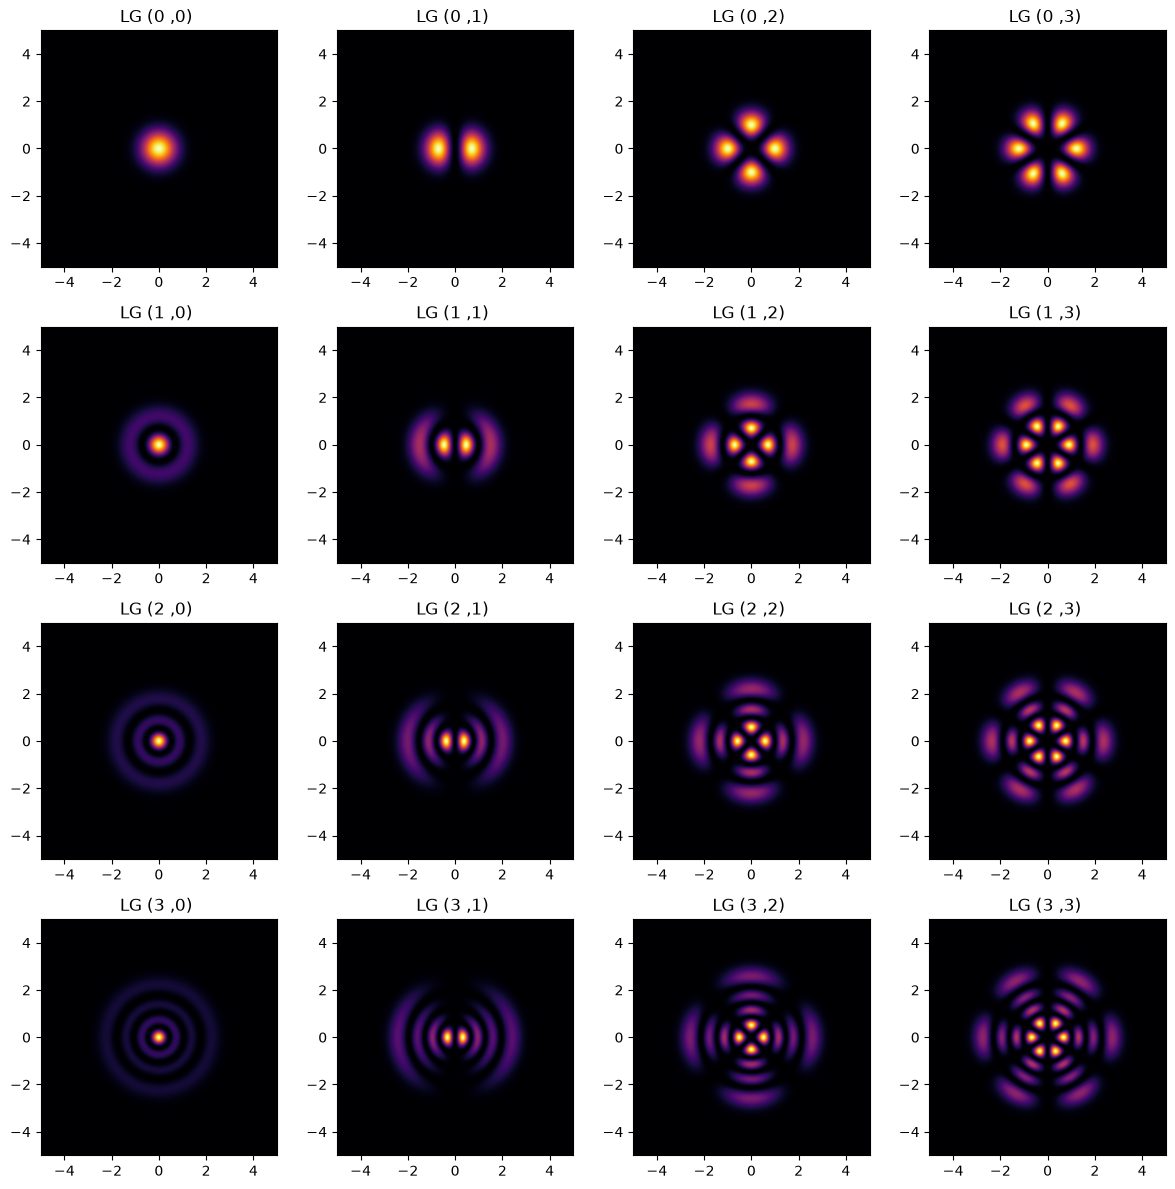

In [12]:
def sinusoidal_laguerre_gauss (p , l , X , Y , w0 =1.0) :
    """
    Parameters
    4 p ( int ) : Radial index ( p >= 0)
    5 l ( int ) : Azimuthal index
    6 X , Y ( ndarray ) : Meshgrid coordinates
    7 w0 ( float ) : Beam waist
    8
    9 Returns
    10 U ( complex ndarray ) : Complex field amplitude
    11 """

    r = np . sqrt ( X **2 + Y **2)
    phi = np . arctan2 (Y , X )
    rho = 2 * r **2 / w0 **2
    L = genlaguerre (p , abs ( l ) ) ( rho )
    norm = np . sqrt (2 * factorial ( p ) / ( np . pi * factorial ( p + abs ( l ) ) ) )
    U = ( norm * ( np . sqrt (2) * r / w0 ) ** abs ( l ) * L * np . exp ( - r **2 / w0 **2) * np . cos ( l * phi ) )

    return U

fig , axes = plt . subplots (4 , 4 , figsize =(12 , 12) )
modes = [( p , l ) for p in range (4) for l in range (4) ]
x = np . linspace ( -5 , 5 , 400)
y = np . linspace ( -5 , 5 , 400)
X , Y = np . meshgrid (x , y )
for ax , (p , l ) in zip ( axes . flatten () , modes ) :
    U = sinusoidal_laguerre_gauss (p , l , X , Y )
    intensity = np . abs ( U ) **2
    ax.imshow (intensity , extent =( -5 , 5 , -5 , 5) , cmap = 'inferno' )
    ax.set_title(f'LG ({ p } ,{ l }) ')

plt . tight_layout()
plt . show()